# Weather Forecast — Vinga A Station (SMHI)
Daily min/max temperature prediction using Machine Learning.

**Station:** Vinga A (71380) | **Lat:** 57.6322 | **Lon:** 11.6048  
**Data range:** 2016-02-01 → 2026-01-31  
**Target:** Predict next N days of min/max air temperature (°C)

## 1. Imports

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RANDOM_STATE = 42
FORECAST_HORIZON = 30
DATA_FILE = "/content/clean_data.csv"


## 2. Data Loading & Parsing

The SMHI file has a multi-line header (metadata rows) before the actual data.  
We skip those and parse the semicolon-separated temperature columns.

In [48]:
df = pd.read_csv(DATA_FILE)
df = df.rename(columns={"ds": "date", "y": "temp"})
df["date"] = pd.to_datetime(df["date"])
df = df[["date", "temp"]].dropna().sort_values("date").reset_index(drop=True)
print(f"Rows: {len(df)} | Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()



Rows: 7428 | Date range: 1996-04-02 → 2026-01-31


,date,temp
0,1996-04-02,-1.00
1,1996-04-03,2.70
2,1996-04-04,3.00
3,1996-04-05,2.10
4,1996-04-06,4.65


## 3. Exploratory Data Analysis

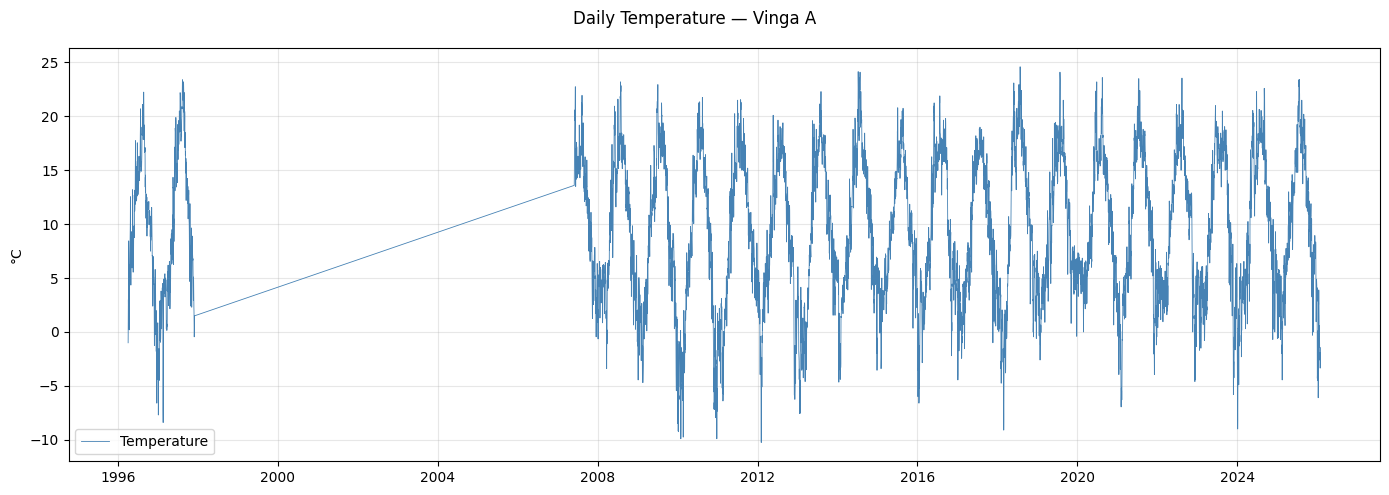

In [49]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["date"], df["temp"], color="steelblue", linewidth=0.6, label="Temperature")
ax.set_ylabel("°C")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Daily Temperature — Vinga A")
plt.tight_layout()
plt.show()


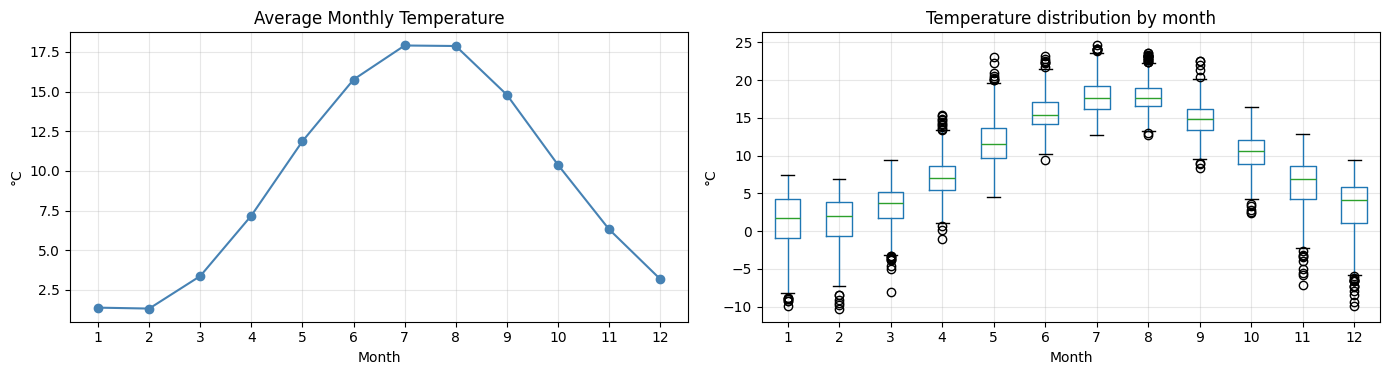

          temp
count  7428.00
mean      9.49
std       6.67
min     -10.25
25%       4.40
50%       9.38
75%      15.35
max      24.60


In [50]:
df["month"] = df["date"].dt.month
monthly = df.groupby("month")["temp"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
monthly.plot(ax=axes[0], marker="o", color="steelblue")
axes[0].set_title("Average Monthly Temperature")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("°C")
axes[0].set_xticks(range(1, 13))

df.boxplot(column="temp", by="month", ax=axes[1])
axes[1].set_title("Temperature distribution by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("°C")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(df[["temp"]].describe().round(2))




## 4. Feature Engineering

We create lag features, rolling statistics, and calendar features that give the model
information about recent temperature history and the seasonal cycle.

In [51]:
def build_features(df: pd.DataFrame, lags: list[int], windows: list[int]) -> pd.DataFrame:
    feat = df.copy()

    feat["day_of_year"] = feat["date"].dt.dayofyear
    feat["month"]       = feat["date"].dt.month
    feat["week"]        = feat["date"].dt.isocalendar().week.astype(int)
    feat["year"]        = feat["date"].dt.year

    for k in [1, 2]:
        feat[f"sin_{k}"] = np.sin(2 * np.pi * k * feat["day_of_year"] / 365.25)
        feat[f"cos_{k}"] = np.cos(2 * np.pi * k * feat["day_of_year"] / 365.25)

    for lag in lags:
        feat[f"temp_lag{lag}"] = feat["temp"].shift(lag)

    for w in windows:
        feat[f"temp_roll{w}_mean"] = feat["temp"].shift(1).rolling(w).mean()
        feat[f"temp_roll{w}_std"]  = feat["temp"].shift(1).rolling(w).std()

    return feat.dropna()


LAGS    = [1, 2, 3, 7, 14]
WINDOWS = [7, 14, 30]

features = build_features(df, LAGS, WINDOWS)
print(f"Feature matrix: {features.shape}")
features.head(3)


Feature matrix: (7398, 21)


,date,temp,month,day_of_year,week,year,sin_1,cos_1,sin_2,cos_2,...,temp_lag2,temp_lag3,temp_lag7,temp_lag14,temp_roll7_mean,temp_roll7_std,temp_roll14_mean,temp_roll14_std,temp_roll30_mean,temp_roll30_std
30,1996-05-02,9.30,5,123,18,1996,0.855075,-0.518505,-0.886721,-0.462305,...,6.0,6.05,7.15,6.75,6.428571,1.064134,7.785714,2.073220,5.815000,2.985458
31,1996-05-03,9.25,5,124,18,1996,0.846029,-0.533137,-0.902099,-0.431530,...,7.1,6.00,7.00,7.00,6.735714,1.519790,7.967857,2.087196,6.158333,2.758313
32,1996-05-04,7.75,5,125,18,1996,0.836733,-0.547611,-0.916409,-0.400244,...,9.3,7.10,4.35,8.85,7.057143,1.797551,8.128571,2.093554,6.376667,2.734257


## 5. Train / Test Split

We use a chronological split (no shuffling) — the last `FORECAST_HORIZON` days are the held-out test set.

In [52]:
TARGET_COL   = "temp"
DROP_COLS    = ["date", "temp", "month"]
FEATURE_COLS = [c for c in features.columns if c not in DROP_COLS]

X = features[FEATURE_COLS].values
y = features[TARGET_COL].values
dates = features["date"].values

split_idx        = len(X) - FORECAST_HORIZON
X_train, X_test  = X[:split_idx], X[split_idx:]
y_train, y_test  = y[:split_idx], y[split_idx:]
dates_test       = dates[split_idx:]

print(f"Train: {split_idx} rows  |  Test: {len(X_test)} rows")
print(f"Test period: {pd.Timestamp(dates_test[0]).date()} → {pd.Timestamp(dates_test[-1]).date()}")


Train: 7368 rows  |  Test: 30 rows
Test period: 2026-01-02 → 2026-01-31


## 6. Model Training

Two models are trained side-by-side: Random Forest and Gradient Boosting.  
Both use `MultiOutputRegressor` to predict T min and T max simultaneously.

In [53]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE
    ),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"  {name} trained.")


  Random Forest trained.
  Gradient Boosting trained.


## 7. Evaluation on Test Set

In [54]:
def evaluate(model, X, y_true, name=""):
    y_pred = model.predict(X)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    return pd.DataFrame([{"model": name, "MAE": round(mae, 3),
                          "RMSE": round(rmse, 3), "R²": round(r2, 3)}]), y_pred

results_list, preds = [], {}
for name, model in trained.items():
    res, pred = evaluate(model, X_test, y_test, name)
    results_list.append(res)
    preds[name] = pred

results = pd.concat(results_list, ignore_index=True)
results


,model,MAE,RMSE,R²
0,Random Forest,1.516,1.927,0.451
1,Gradient Boosting,1.623,1.924,0.452


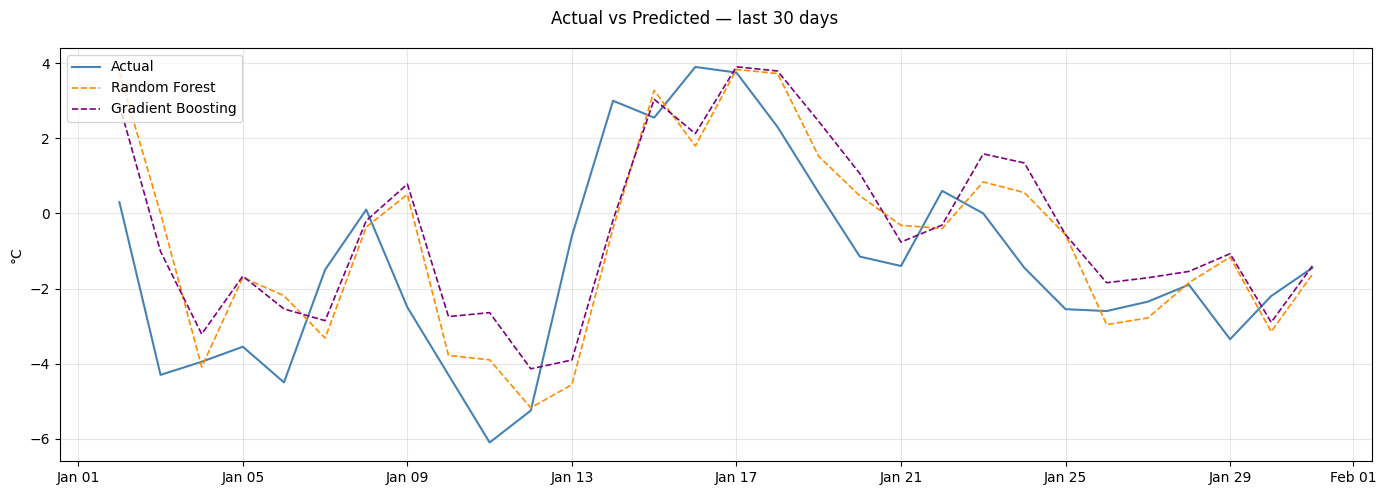

In [55]:
# Visualise actual vs predicted for both models
fig, ax = plt.subplots(figsize=(14, 5))
colors = {"Random Forest": "darkorange", "Gradient Boosting": "purple"}
date_index = pd.to_datetime(dates_test)

ax.plot(date_index, y_test, label="Actual", color="steelblue", linewidth=1.5)
for mname, pred in preds.items():
    ax.plot(date_index, pred, label=mname, color=colors[mname], linestyle="--", linewidth=1.2)
ax.set_ylabel("°C")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.suptitle(f"Actual vs Predicted — last {FORECAST_HORIZON} days")
plt.tight_layout()
plt.show()


## 8. Feature Importance

Which signals matter most? (Random Forest native importance)

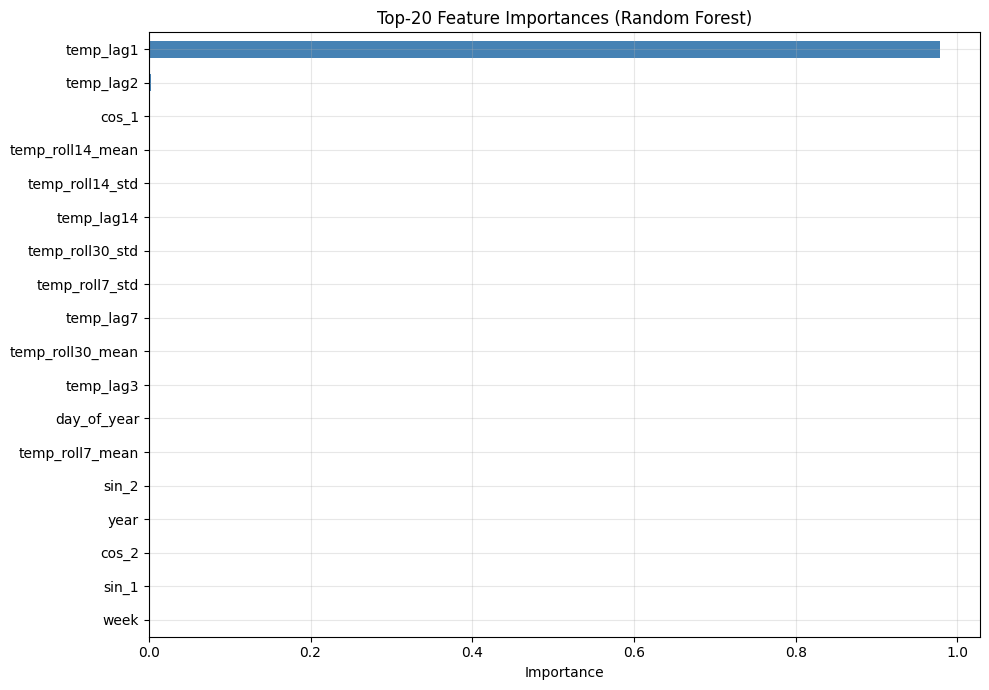

In [56]:
rf_model = trained["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
top20 = importances.nlargest(20).sort_values()

top20.plot(kind="barh", figsize=(10, 7), color="steelblue")
plt.title("Top-20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 9. Future Forecast

Generate a `FORECAST_HORIZON`-day forecast beyond the last known date using the best model.  
Because future lag values are unknown, we use **recursive forecasting** — each predicted day
feeds back as a lag feature for the next day.

Best model: Random Forest


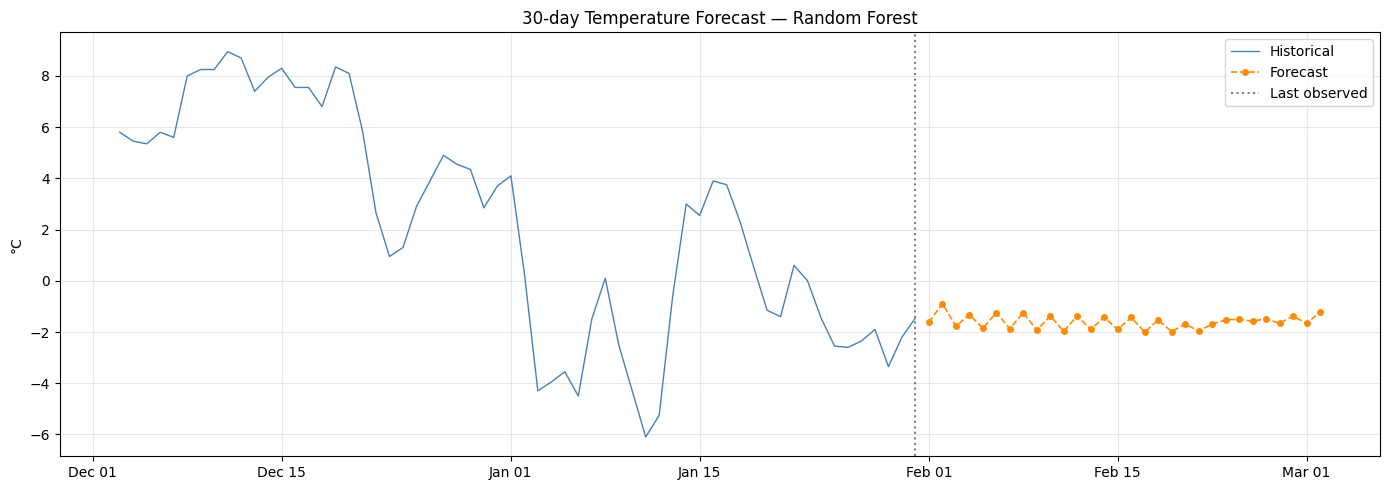

,date,temp
0,2026-02-01,-1.62
1,2026-02-02,-0.89
2,2026-02-03,-1.77
3,2026-02-04,-1.32
4,2026-02-05,-1.86


In [ ]:
FORECAST_YEARS = 4
FORECAST_DAYS  = FORECAST_YEARS * 365

best_model_name = results.groupby("model")["MAE"].mean().idxmin()
print(f"Best model: {best_model_name}")

forecast_df = recursive_forecast(
    trained[best_model_name], df.copy(), FORECAST_DAYS, LAGS, WINDOWS
)

context = df.tail(60)
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(context["date"], context["temp"], color="steelblue", linewidth=1, label="Historical")
ax.plot(forecast_df["date"], forecast_df["temp"], color="darkorange",
        linewidth=1, label=f"{FORECAST_YEARS}-year Forecast")
ax.axvline(df["date"].iloc[-1], color="gray", linestyle=":", linewidth=1.5, label="Last observed")
ax.set_ylabel("°C")
ax.set_title(f"{FORECAST_YEARS}-year Temperature Forecast — {best_model_name}")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

forecast_df.head()



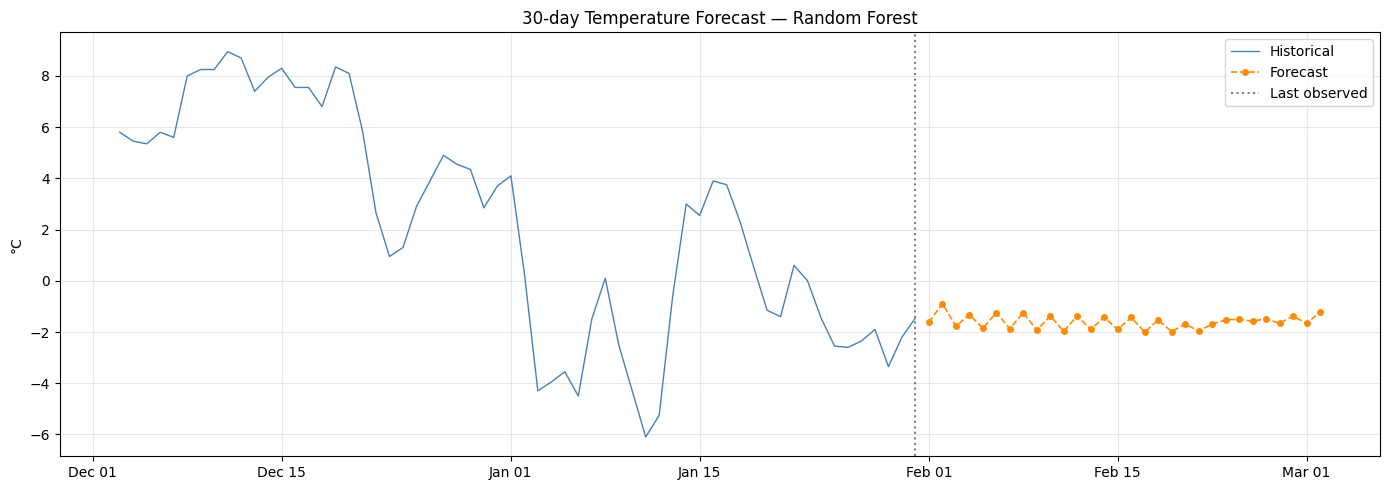

In [58]:
# Plot: last 60 days of history + forecast
context_days = 60
context = df.tail(context_days)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(context["date"], context["temp"], color="steelblue", linewidth=1, label="Historical")
ax.plot(forecast_df["date"], forecast_df["temp"], "o--", color="darkorange",
        linewidth=1.2, markersize=4, label="Forecast")
ax.axvline(df["date"].iloc[-1], color="gray", linestyle=":", linewidth=1.5, label="Last observed")
ax.set_ylabel("°C")
ax.set_title(f"{FORECAST_HORIZON}-day Temperature Forecast — {best_model_name}")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.show()


## 10. Export Forecast

Save the forecast table to CSV for downstream use.

In [59]:
forecast_df.to_csv("forecast_output.csv", index=False)
print("Forecast saved to forecast_output.csv")
forecast_df


Forecast saved to forecast_output.csv


,date,temp
0,2026-02-01,-1.62
1,2026-02-02,-0.89
2,2026-02-03,-1.77
3,2026-02-04,-1.32
4,2026-02-05,-1.86
5,2026-02-06,-1.24
6,2026-02-07,-1.87
7,2026-02-08,-1.24
8,2026-02-09,-1.93
9,2026-02-10,-1.37
